# Covolution 2D Chapter 8 Workshop 1

## Import module and Create 2D matrix

In [5]:
import cv2
import numpy as np

image = np.array([
    [1, 0, 2, 1, 0 ],
    [0, 2, 3, 0, 1 ],
    [1, 0, 1, 1, 2 ],
    [0, 2, 2, 0, 3 ],
    [0, 4, 1, 2, 0 ]
])

image = image/5

## Create Kernel 2D (3x3)

In [6]:
kernel1 = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])  

# Convolution with kernel1 2D
im2 = cv2.filter2D(src=image, ddepth=-1, kernel=kernel1)

## Show result from convolution

In [7]:
im2_int = (im2 * 5).astype('int')
print("Convolution with kernel1 2D:")
print(im2_int)

Convolution with kernel1 2D:
[[ 0  7 -3 -6  0]
 [ 0  4  0 -3  0]
 [ 0  5 -3  0  0]
 [ 0  3 -3  0  0]
 [ 0  5 -6  0  0]]


# Feature Map Chapter 8 Workshop 2

In [8]:
# Load image in grayscale
image = cv2.imread('image/building.jpg', 0)  

if image is None:
    raise Exception("Image not found")

# Create a kernel for convolution to detect vertical edges
kernel1 = np.array([
    [-1, 0, 1],
    [-3, 0, 3],
    [-1, 0, 1]
])

# Convolution with kernel1 2D
fea_map = cv2.filter2D(src=image, ddepth=-1, kernel=kernel1)

# Show Original image and feature map
cv2.imshow('Original Image', image)
cv2.imshow('Feature Map', fea_map)

# Save the feature map as an image
# cv2.imwrite('feature_map1.jpg', fea_map)

cv2.waitKey()
cv2.destroyAllWindows()

# Pooling Chapter 8 Workshop 3

## Define Array and load module

In [9]:
import numpy as np
from tensorflow.keras import Sequential
from tensorflow.keras.layers import MaxPooling2D, AveragePooling2D

image = np.array([
    [2, 3, 4, 2],
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 8, 7, 6]
])

print(image.shape)  # (4, 4)

(4, 4)


## Reshape to tuple (image index, W, H, chanel)

In [10]:
# reshape the image to 1x4x4x1 : 1 rows, 4 width, 4 height, 1 channel
arr = image.reshape(1, 4, 4, 1).astype('float32')
print(image.shape)  # (1, 4, 4, 1)
print(image)

(4, 4)
[[2 3 4 2]
 [1 2 3 4]
 [5 6 7 8]
 [9 8 7 6]]


## Create model

In [11]:
# Create Sequential model just only for pooling layer
model = Sequential()
model.add(MaxPooling2D(pool_size=(2, 2)))
# model.add(AveragePooling2D(pool_size=(2, 2)))

# Predict output
output = model.predict(arr)

output = np.squeeze(output)  # remove the first dimension
print(output.shape)  # (2, 2)
print(output)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
(2, 2)
[[3. 4.]
 [9. 8.]]


# Pooling after Convolution Chapter 8 Workshop 4

## Load image and import Pillow module 

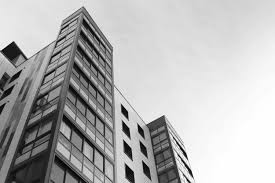

In [26]:
from PIL import Image, ImageOps

imgfile = 'image/building.jpg'
image = Image.open(imgfile).convert('L')  # Convert to grayscale
image

In [27]:
pixel = np.array(image)
print(pixel.shape)  # (height, width)
# print(pixel)

(183, 275)


## Pooling 

In [ ]:
arr = pixel.reshape(1, pixel.shape[0], pixel.shape[1], 1)

# Create Sequential model just only for pooling layer
model = Sequential()
model.add(MaxPooling2D(pool_size=(2, 2)))
# model.add(AveragePooling2D(pool_size=(2, 2)))

# Predict output
output = model.predict(arr)
output = np.squeeze(output)  # remove the first dimension
print(output.shape)  # (height/2, width/2)
outputImage = Image.fromarray(output)
# show the image
# outputImage.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
(91, 137)


## Sample Covolution model 

In [ ]:
"""


model = Sequential()

# Add a convolutional layer with 8 filters, 3x3 kernel size, and ReLU activation function
# Input shape is (28, 28, 1) for grayscale images
model.add(Conv2D(8, (3, 3), activation='relu', input_shape=(28, 28, 1)))

# Add a max pooling layer with 2x2 pool size
model.add(MaxPooling2D(pool_size=(2, 2)))

# Add a convolutional layer with 16 filters, 3x3 kernel size, and ReLU activation function
model.add(Conv2D(16, (3, 3), activation='relu'))
# Add a max pooling layer with 2x2 pool size
model.add(MaxPooling2D(pool_size=(2, 2)))

# Add Neural Network layer with 128 neurons and ReLU activation function
model.add(Flatten())
model.add(Dense(128, activation='relu'))
# Add output layer with 10 neurons (for 10 classes) and softmax activation function
model.add(Dense(10, activation='softmax'))


"""

# Create model and monitor kernel Chapter 8 Workshop 5

## Create model

In [1]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import numpy as np
import matplotlib.pyplot as plt

input_shape = (100, 100, 3)  # Example input shape for grayscale images

# Create a Sequential model
model = Sequential()
# Add a convolutional layer with 32 filters, 3x3 kernel size, and ReLU activation function
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
# Add a max pooling layer with 2x2 pool size
model.add(MaxPooling2D(pool_size=(2, 2)))

# Add a convolutional layer with 64 filters, 3x3 kernel size, and ReLU activation function
model.add(Conv2D(64, (3, 3), activation='relu'))
# Add a max pooling layer with 2x2 pool size
model.add(MaxPooling2D(pool_size=(2, 2)))

# Add a convolutional layer with 128 filters, 3x3 kernel size, and ReLU activation function
model.add(Conv2D(128, (3, 3), activation='relu'))
# Add a max pooling layer with 2x2 pool size
model.add(MaxPooling2D(pool_size=(2, 2)))

# Add a flattening layer to convert the 3D feature maps to 1D feature vectors
model.add(Flatten())
# Add a fully connected layer with 128 neurons and ReLU activation function
model.add(Dense(128, activation='relu'))
# Add output layer with 10 neurons (for 10 classes) and softmax activation function
model.add(Dense(3, activation='softmax'))

# Model summary
model.summary()


d:\Programming_File\Environment\tf\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,732,163 (6.61 MB)

 Trainable params: 1,732,163 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

## Watch kernel

In [2]:
print('"model.layers" type:' ,type(model.layers))
print(model.layers)
for layer in model.layers:
    if 'conv' not in layer.name:
        continue
    # Get the weights of the layer
    kernels, biases = layer.get_weights()
    # Print the shape of the kernels
    print(layer.name, ' shape', kernels.shape)

"model.layers" type: <class 'list'>
[<Conv2D name=conv2d, built=True>, <MaxPooling2D name=max_pooling2d, built=True>, <Conv2D name=conv2d_1, built=True>, <MaxPooling2D name=max_pooling2d_1, built=True>, <Conv2D name=conv2d_2, built=True>, <MaxPooling2D name=max_pooling2d_2, built=True>, <Flatten name=flatten, built=True>, <Dense name=dense, built=True>, <Dense name=dense_1, built=True>]
conv2d  shape (3, 3, 3, 32)
conv2d_1  shape (3, 3, 32, 64)
conv2d_2  shape (3, 3, 64, 128)


In [3]:
print('"model.layers" type:' ,type(model.layers[0]))
print(model.layers[0])

"model.layers" type: <class 'keras.src.layers.convolutional.conv2d.Conv2D'>
<Conv2D name=conv2d, built=True>


## Watch specific layers

In [4]:
layer_index = 0
# Get the weights of the convolutional layer
layer = model.layers[layer_index]
# Get the weights of the layer
kernels, biases = layer.get_weights()
# Print the shape of the kernels
print(kernels.shape)  # (3, 3, 3, 32)

(3, 3, 3, 32)


## Show kernel's image

### Nomalization

In [5]:
k_min, k_max = kernels.min(), kernels.max()

# Normalize to [0, 1]
kernels = (kernels - k_min) / (k_max - k_min)

kernel_idx = 0
# Get the kernel of the filter follow kernel index
kernel_i = kernels[:, :, 0, kernel_idx]
print(kernel_i.round(2))

[[0.28 0.24 0.81]
 [0.91 0.72 0.79]
 [0.68 0.39 0.66]]


### Show kernel image

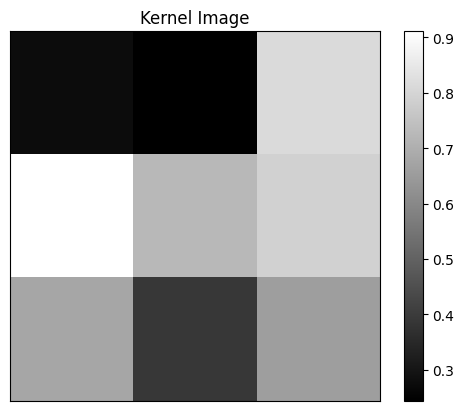

In [6]:
# Display the kernel as an image
plt.imshow(kernel_i, cmap='gray')
plt.colorbar()  # Add a colorbar to show the scale
plt.xticks([])  # Remove x ticks
plt.yticks([])  # Remove y ticks
plt.title("Kernel Image")
plt.show()

32


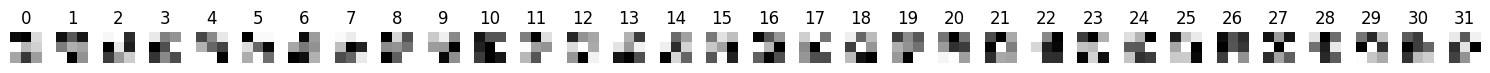

In [7]:
# Get the number of kernels in the first convolutional layer
num_kernels = kernels.shape[-1]
print(num_kernels)  # Number of filters in the layer

# Create a figure with subplots
fig, axes = plt.subplots(1, num_kernels, figsize=(15, 5))

# Loop through each kernel and display it
for i in range(num_kernels):
    kernel_image = kernels[:, :, 0, i]  # Extract the kernel for the first channel
    axes[i].imshow(kernel_image, cmap='gray')
    axes[i].set_title(f"{i}")
    axes[i].axis('off')  # Turn off axis

plt.tight_layout()
plt.show()

# Feature Map Chapter 8 Workshop 6

## Load image

<class 'PIL.Image.Image'>


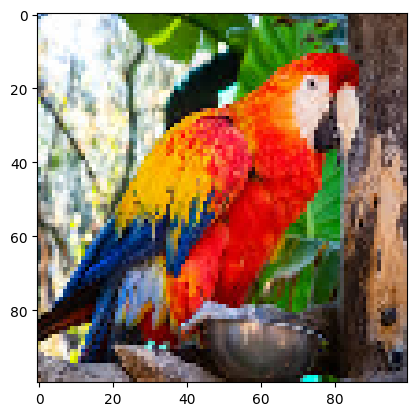

In [13]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import numpy as np

# Load image and convert to 100x100 pixels
img = load_img('./image/parrot.jpg', target_size=(100, 100))
print(type(img))  # <class 'PIL.JpegImagePlugin.JpegImageFile'>
plt.imshow(img)
plt.show()

## Convert to array

In [9]:
# Convert image to array
img_array = img_to_array(img)
print(img_array.shape)  # (100, 100, 3)
print('max pixel value:', np.max(img_array))  

(100, 100, 3)
max pixel value: 255.0


In [14]:
img = np.expand_dims(img_array, axis=0)  # Add batch dimension
print(type(img))  # <class 'numpy.ndarray'>
print(img.shape)  # (1, 100, 100, 3)

<class 'numpy.ndarray'>
(1, 100, 100, 3)


## The first Conv2D

In [15]:
layer_index = 0  # Index of the layer to visualize
md = Model(inputs=model.inputs, outputs=model.layers[layer_index].output)
feature_maps = md.predict(img)
print(feature_maps.shape)  # (1, 100, 100, 32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
(1, 98, 98, 32)


d:\Programming_File\Environment\tf\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 100, 100, 3))
  warnings.warn(msg)


## Nomalization

In [17]:
f_min, f_max = feature_maps.min(), feature_maps.max()
# Normalize to [0, 1]
feature_maps = (feature_maps - f_min) / (f_max - f_min)
print('min:', feature_maps.min(), 'max:', feature_maps.max())

min: 0.0 max: 1.0


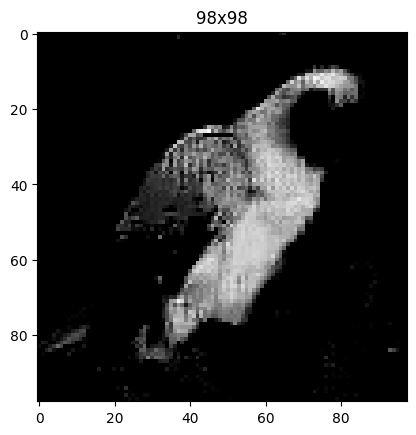

In [20]:
sample_index = 0  # Index of the sample in the batch
fea_index = 0  # Index of the feature map to visualize
feature_map_i = feature_maps[sample_index, :, :, fea_index]  # Extract the feature map

plt.imshow(feature_map_i, cmap='gray')
# plt.colorbar()  # Add a colorbar to show the scale
# plt.xticks([])  # Remove x ticks
# plt.yticks([])  # Remove y ticks
plt.title("{}x{}".format(feature_map_i.shape[0], feature_map_i.shape[1]))
plt.show()

## Show all feature maps

32


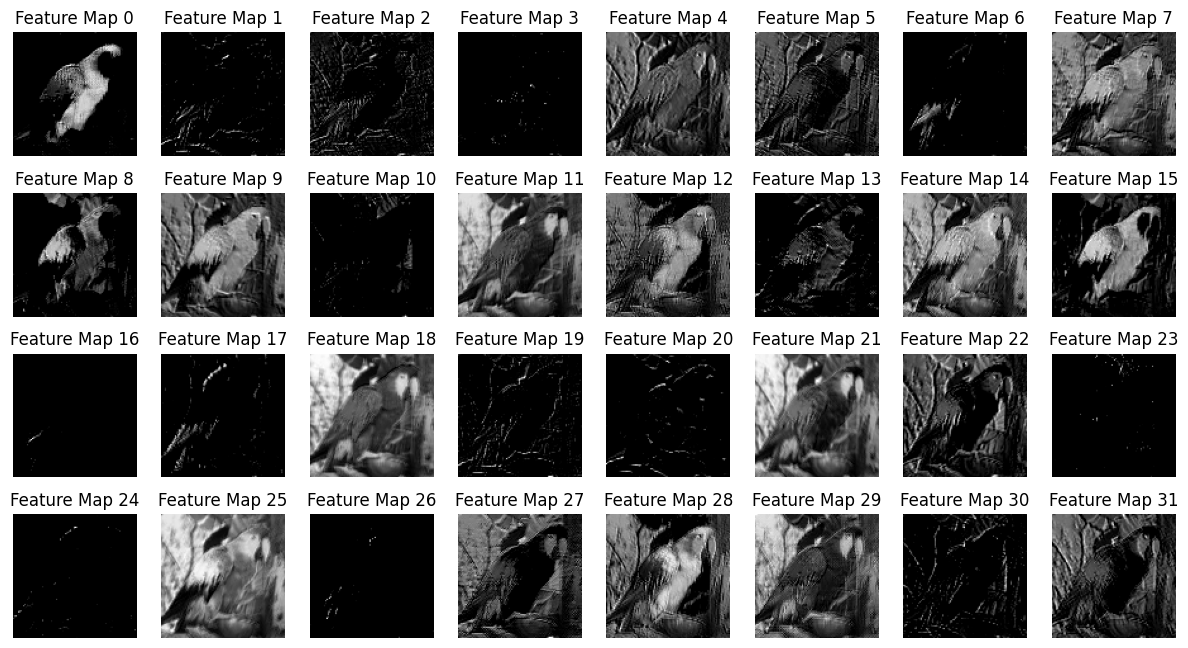

In [22]:
## Show all feature maps
num_feature_maps = feature_maps.shape[-1]  # Number of feature maps
print(num_feature_maps)  # Number of filters in the layer
# Create a figure with subplots
fig, axes = plt.subplots(4, 8, figsize=(15, 8))
# Loop through each feature map and display it
for i in range(num_feature_maps):
    feature_map_i = feature_maps[sample_index, :, :, i]  # Extract the feature map for the first sample
    ax = axes[i // 8, i % 8]  # Get the corresponding subplot axis
    ax.imshow(feature_map_i, cmap='gray')
    ax.set_title(f"Feature Map {i}")
    ax.axis('off')  # Turn off axis

## MaxPooling 1 layer

In [28]:
layer_index = 1  # Index of the layer to visualize
md2 = Model(inputs=model.inputs, outputs=model.layers[layer_index].output)
feature_maps2 = md2.predict(img)
print(feature_maps2.shape)  # (1, 50, 50, 64)
f_min, f_max = feature_maps2.min(), feature_maps2.max()
# Normalize to [0, 1]
feature_maps2 = (feature_maps2 - f_min) / (f_max - f_min)
print('min:', feature_maps2.min(), 'max:', feature_maps2.max())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
(1, 49, 49, 32)
min: 0.0 max: 1.0


## Show all feature maps layer 2 (index 1)

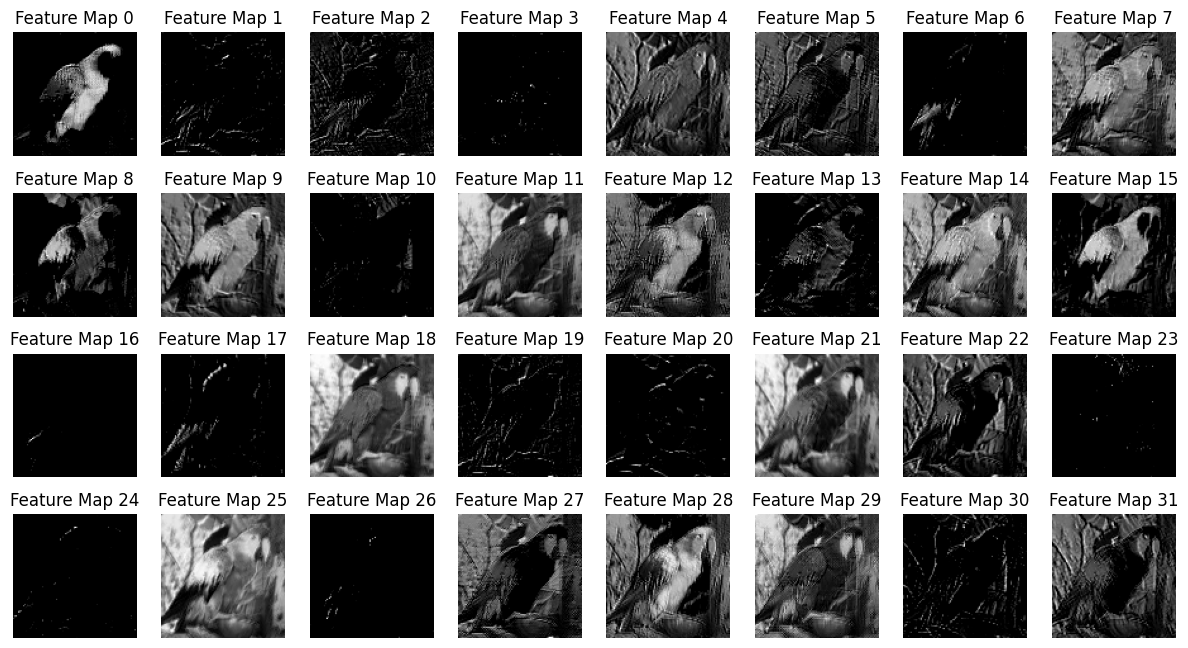

In [31]:
sample_index = 0  # Index of the sample in the batch
feature_map = feature_maps2[sample_index,:,:,fea_index]  # Get the first sample

# Create a figure with subplots
fig, axes = plt.subplots(4, 8, figsize=(15, 8))
# Loop through each feature map and display it
for i in range(num_feature_maps):
    feature_map_i = feature_maps[sample_index, :, :, i]  # Extract the feature map for the first sample
    ax = axes[i // 8, i % 8]  # Get the corresponding subplot axis
    ax.imshow(feature_map_i, cmap='gray')
    ax.set_title(f"Feature Map {i}")
    ax.axis('off')  # Turn off axis